# Привет уважаемый соискатель!
 Тебе предстоит пройти пару простых заданий по глубокому обучению. Это нормально не всегда понимать сразу как
 сделать ту или иную часть, видь у тебя есть возможность разобраться во всём самому! А этот навык куда ценнее
 знаний.
 Отметим сразу, что весь код написанный нами, есть лишь один из возможных путей решения задачи и ты не обязан ему
 следовать. Возможно, ты решишь использовать другие, более удобные, решения. Но как и в случае использования
 наших подсказок, так и без них, мы рекомендуем понимать, что ты пишешь и зачем. Мы будем спрашивать на собесе!
 Но ты не пугайся) Лучше разберись что и как.

In [74]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Задания и оценивание
В тестировании присутствует 3 части:
- Составление датаеста
- Конструкция архитектуры нейросети
- Обучение и аналитика

Каждая из них представляет собой важный этап работы Ml-щика нашей команды, поэтому постарайся сделать их все.
Все они приносят равное количество баллов. В каждой части есть задание со звёздочкой, его делать не обязательно -
 но если ты всё-таки его сделаешь, то это поможет нам оценить твои компетенции.


Скажем пару слов о данных. Признаки представляют из себя из себя 11 непрерывных переменных, таргет - целочисленную оценку от 1 до 10. Подумай, что это за тип задачи.

In [75]:
def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(42)

seed_everything(42)

# Составление датаеста

- Загрузи данные из файла our data. (тут тебе может помочь библиотека pandas)
- Раздели их по переменным X и Y.
- Сконструируй класс MyDataset. (про такого функионал класса можешь почитать [тут](https:pytorch.org/tutorials/beginner/basics/data_tutorial.html))

- "*" Импортируй линейную регрессию из библиотеки sklearn и обучи её на тех же данных. Ура! теперь у нас есть безлайн!


Загрузите данные и разделите на X, Y

In [76]:
data = pd.read_csv('my_data.csv', sep=';').reset_index(drop=True)
data

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,target
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [77]:
data.isnull().sum()

,0
feature_1,0
feature_2,0
feature_3,0
feature_4,0
feature_5,0
feature_6,0
feature_7,0
feature_8,0
feature_9,0
feature_10,0


In [78]:
X = data.drop(columns=['target'])
y = data['target']

In [79]:
y.unique() # тогда решаем задачу классификации

array([5, 6, 7, 4, 8, 3])

In [80]:
# нейросетевые модели могут работать только с классами 0,1,2,3...
unique_classes = sorted(y.unique())
class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
y = y.map(class_mapping)
y.unique()

array([2, 3, 4, 1, 5, 0])

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [105]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, mean_squared_error
)

def calculate_metrics(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average='macro',)
    recall_macro = recall_score(y_true, y_pred, average='macro')
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"{model_name} Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision_macro:.4f}")
    print(f"Recall (macro): {recall_macro:.4f}")
    print(f"F1-Score (macro): {f1_macro:.4f}")

    return {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro
    }

In [114]:
from sklearn.linear_model import LogisticRegression, LinearRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)
lr_metrics = calculate_metrics(y_val, y_pred, model_name='Logistic Regression')

Logistic Regression Metrics:
Accuracy: 0.5500
Precision (macro): 0.2399
Recall (macro): 0.2267
F1-Score (macro): 0.2091


In [116]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred = linear_reg.predict(X_val)
linear_reg_metrics = calculate_metrics(y_val, y_pred.round(), model_name='Linear Regression') # приведем предсказания регрессии к классам через round

Linear Regression Metrics:
Accuracy: 0.5719
Precision (macro): 0.2550
Recall (macro): 0.2464
F1-Score (macro): 0.2393


Создайте класс DataSet - https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [82]:
class MyDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# Сконструируйте класс нейронной сети
В этом задании тебе предстоит сконструировать полносвязную двухслойную нейронную сеть.

- Вспомните какие сущности необходимы для обучения нейронной сети и включите их в атрибуты класса.
- Основываясь на типе данной задачи выберете подходящую лосс функцию.
- На основе требований первых двух пунктов заполните методы forward и training_step
- "*" Настрой обучение батчами (это не обязательно делать в противном случае)

Напоминаем, что не обязательно пользоваться предлагаемым шаблоном! Если вы знаете более быстрые и простые пути,
то будет интересно на них посмотреть.

In [83]:
class MyNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, learning_rate=0.001):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, num_classes)
        )

        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        self.loss = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.network(x)

    def training_step(self, train_data):
        x, y = train_data

        self.optimizer.zero_grad()
        predictions = self.forward(x)
        loss = self.loss(predictions, y)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def validation_step(self, val_data):
        x, y = val_data

        with torch.no_grad():
            predictions = self.forward(x)
            loss = self.loss(predictions, y)

        return loss.item()

# Обучение и аналитика
В этом задании тебе предстоит обучить сконструированную архитектуру.

- Создай объект класса MyDataset и MyNet, а также других атрибутов, если ваше решение их предусматривает.
- Напишите цикл обучения нейронной сети.
- Обучите нейронную сеть и оцените финальной качество на валидационном датасете.
- "*" Каждый N-ый шаг изображайте на графике, как менялось значение лосс функции на тестовых данных и
на части валидационных данных.

In [84]:
dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)
model = MyNet(input_size=X.shape[1], hidden_size=64, num_classes=len(y.unique()))

In [117]:
model = MyNet(
    input_size=X.shape[1],
    hidden_size=64,
    num_classes=num_classes,
    learning_rate=0.001
)

n_epochs = 100
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

train_epoch_losses = []
val_epoch_losses = []

for epoch in range(n_epochs):
    model.train()
    total_train_loss = 0.0
    batch_count = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch+1}/{n_epochs} [Train]')

    for batch_idx, data in enumerate(progress_bar):
        loss_value = model.training_step(data)
        total_train_loss += loss_value
        batch_count += 1
        progress_bar.set_postfix({'train_loss': f'{loss_value:.4f}'})

    avg_train_loss = total_train_loss / batch_count if batch_count > 0 else 0.0
    train_epoch_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    val_batch_count = 0

    with torch.no_grad():
        for val_data in val_loader:
            val_loss_value = model.validation_step(val_data)
            total_val_loss += val_loss_value
            val_batch_count += 1

    avg_val_loss = total_val_loss / val_batch_count if val_batch_count > 0 else 0.0
    val_epoch_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

Epoch 1/100 [Train]: 100%|██████████| 40/40 [00:00<00:00, 81.76it/s, train_loss=1.3215]


Epoch 1: Train Loss: 1.4957, Val Loss: 1.2300


Epoch 2/100 [Train]: 100%|██████████| 40/40 [00:00<00:00, 92.83it/s, train_loss=1.2419]


Epoch 2: Train Loss: 1.2854, Val Loss: 1.1870


Epoch 3/100 [Train]: 100%|██████████| 40/40 [00:00<00:00, 79.37it/s, train_loss=1.1275]


...

Epoch 98: Train Loss: 0.9258, Val Loss: 0.9482


Epoch 99/100 [Train]: 100%|██████████| 40/40 [00:00<00:00, 150.28it/s, train_loss=0.8108]


Epoch 99: Train Loss: 0.9218, Val Loss: 0.9325


Epoch 100/100 [Train]: 100%|██████████| 40/40 [00:00<00:00, 173.46it/s, train_loss=0.8094]


Epoch 100: Train Loss: 0.9233, Val Loss: 0.9435


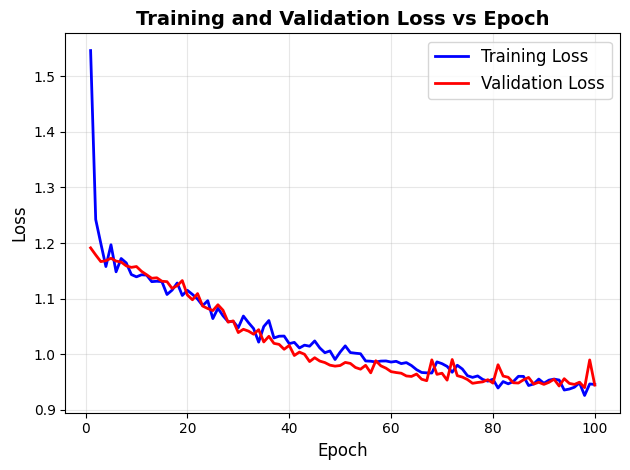

In [86]:
import matplotlib.pyplot as plt

plt.plot(range(1, n_epochs + 1), train_epoch_losses, 'b-', linewidth=2, label='Training Loss')
plt.plot(range(1, n_epochs + 1), val_epoch_losses, 'r-', linewidth=2, label='Validation Loss')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss vs Epoch', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [87]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for val_data in val_loader:
        x, y_ = val_data

        outputs = model(x)

        _, predicted = torch.max(outputs.data, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(y_.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

In [88]:
NN_metrics = calculate_metrics(all_labels, all_predictions, "NN")

NN Metrics:
Accuracy: 0.5594
Precision (macro): 0.2654
Recall (macro): 0.2496
F1-Score (macro): 0.2457


Результаты, мягко скажем, не очень хорошие. Попробуем взять другую модель.

# XGBoost
Нейронные сети - конечно хорошо, но для табличных данных больше подходят методы классического машинного обучения. На данный момент наилучший результат показывают алгоритмы, основанные на решающих деревьях.

Optuna поможет найти оптимальные гиперпараметры для обучения модели.

In [89]:
!pip install xgboost optuna

In [90]:
import optuna
import catboost as cb
import xgboost as xgb

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

def objective_xgboost(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42,
        'eval_metric': 'mlogloss'
    }

    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    return accuracy

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgboost, n_trials=50)

[I 2025-11-10 12:52:30,220] A new study created in memory with name: no-name-7149715e-2a9b-4122-9b1a-37262d506058
[I 2025-11-10 12:52:31,851] Trial 0 finished with value: 0.6375 and parameters: {'max_depth': 4, 'learning_rate': 0.29627733178364235, 'n_estimators': 670, 'min_child_weight': 3, 'gamma': 0.8299920399429572, 'subsample': 0.9304264968661476, 'colsample_bytree': 0.9826834165046443, 'reg_alpha': 0.40040109624537856, 'reg_lambda': 0.24403143348842937}. Best is trial 0 with value: 0.6375.
[I 2025-11-10 12:52:33,192] Trial 1 finished with value: 0.665625 and parameters: {'max_depth': 4, 'learning_rate': 0.283758878845383, 'n_estimators': 313, 'min_child_weight': 10, 'gamma': 0.37824583400387624, 'subsample': 0.8728620026003826, 'colsample_bytree': 0.8684331373730045, 'reg_alpha': 0.24467369155982788, 'reg_lambda': 0.5922976026234698}. Best is trial 1 with value: 0.665625.
[I 2025-11-10 12:52:38,919] Trial 2 finished with value: 0.621875 and parameters: {'max_depth': 9, 'learning_

In [91]:
best_xgb_params = study_xgb.best_params
xgb_model = xgb.XGBClassifier(
    max_depth=best_xgb_params['max_depth'],
    learning_rate=best_xgb_params['learning_rate'],
    n_estimators=best_xgb_params['n_estimators'],
    min_child_weight=best_xgb_params['min_child_weight'],
    gamma=best_xgb_params['gamma'],
    subsample=best_xgb_params['subsample'],
    colsample_bytree=best_xgb_params['colsample_bytree'],
    reg_alpha=best_xgb_params['reg_alpha'],
    reg_lambda=best_xgb_params['reg_lambda'],
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_val)
xgb_metrics = calculate_metrics(y_val, xgb_pred, "XGBoost")

XGBoost Metrics:
Accuracy: 0.6969
Precision (macro): 0.3438
Recall (macro): 0.3485
F1-Score (macro): 0.3456
